In [1]:
import sys
from functools import partial
sys.path.append('../')
from math import log, comb, cos, sin
from numpy.linalg import matrix_power
from spd.OperatorSequence import *
from spd.SparsePauliDynamics import *
from spd.LightPauliDynamics import *
from pauli import *
from quantum_simulation_recipe.spin import Nearest_Neighbour_1d
from quantum_simulation_recipe.trotter import pf, expH
from qiskit.quantum_info import SparsePauliOp, random_statevector
import matplotlib.pyplot as plt
from quantum_simulation_recipe.plot_config import *
set_fontsize(linewidth=2.5)
fig_dir, data_dir = './figs', './data'

In [2]:
n = 10 # 10
t = 5 
r = 50 # 100

dt = t/r
H_model = 'MFI'
Jx, hx, hy = 1, 0.8, 0.9
# n = 21
qimf = Nearest_Neighbour_1d(n, hx=hx, hy=hy, Jx=Jx, pbc=False)
xx_even = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[::2]], num_qubits=n).simplify()
xx_odd = SparsePauliOp.from_sparse_list([*qimf.xx_tuples[1::2]], num_qubits=n).simplify()
x_terms = SparsePauliOp.from_sparse_list([*qimf.x_tuples], num_qubits=n).simplify()
H_list = [x_terms, qimf.y_terms, xx_even, xx_odd] # [xx_even, x_terms, qimf.y_terms,xx_odd]
H_pf2_list = [x_terms, qimf.y_terms, xx_even, xx_odd, xx_odd, xx_even, qimf.y_terms, x_terms] 
H_ordered = sum(H_list)
H_pf2_ordered = sum(H_pf2_list)
dt = t/r
print(f't={t}, r={r}, dt={dt}')
U_dt_ideal = expH(sum(H_ordered), dt, use_jax=False)
U_dt_appro = pf(H_ordered, dt, 2, 1)
# init_state_str = '0'*n
init_state_str = '10'*(n//2)
init_state = Statevector.from_label(init_state_str).data

z1 = SparsePauliOp('I'*(n-1)+'Z', 1)
complete_fnorm = 2**(-n/2)*np.linalg.norm(z1.to_matrix(), ord='fro')

t_num_dense = 50
U_dt_ideal_dense = expH(sum(H_ordered), t/t_num_dense, use_jax=False)
ideal_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_ideal_dense, i)@init_state) for i in range(t_num_dense+1)]
trott_expvals = [expect_value(z1.to_matrix(), matrix_power(U_dt_appro, i)@init_state) for i in range(r+1)]

trott_ops = [matrix_power(U_dt_appro, i) for i in range(r+1)]
ideal_ops = [matrix_power(U_dt_ideal, i) for i in range(r+1)]
trott_obs = [op.conjugate().transpose() @ z1.to_matrix() @ op for op in trott_ops]
ideal_obs = [op.conjugate().transpose() @ z1.to_matrix() @ op for op in ideal_ops]

ops = dt/2*sum(H_pf2_ordered)
obs = z1
print('ops:', ops)
print('obs:', obs)

exp_val_func = partial(exp_val_0101_state_pauli_rep, n_qubits=n)
# exp_val_func = exp_val_all_zeros_pauli_rep

t=5, r=50, dt=0.1
ops: SparsePauliOp(['IIIIIIIIIX', 'IIIIIIIIXI', 'IIIIIIIXII', 'IIIIIIXIII', 'IIIIIXIIII', 'IIIIXIIIII', 'IIIXIIIIII', 'IIXIIIIIII', 'IXIIIIIIII', 'XIIIIIIIII', 'IIIIIIIIIY', 'IIIIIIIIYI', 'IIIIIIIYII', 'IIIIIIYIII', 'IIIIIYIIII', 'IIIIYIIIII', 'IIIYIIIIII', 'IIYIIIIIII', 'IYIIIIIIII', 'YIIIIIIIII', 'IIIIIIIIXX', 'IIIIIIXXII', 'IIIIXXIIII', 'IIXXIIIIII', 'XXIIIIIIII', 'IIIIIIIXXI', 'IIIIIXXIII', 'IIIXXIIIII', 'IXXIIIIIII', 'IIIIIIIXXI', 'IIIIIXXIII', 'IIIXXIIIII', 'IXXIIIIIII', 'IIIIIIIIXX', 'IIIIIIXXII', 'IIIIXXIIII', 'IIXXIIIIII', 'XXIIIIIIII', 'IIIIIIIIIY', 'IIIIIIIIYI', 'IIIIIIIYII', 'IIIIIIYIII', 'IIIIIYIIII', 'IIIIYIIIII', 'IIIYIIIIII', 'IIYIIIIIII', 'IYIIIIIIII', 'YIIIIIIIII', 'IIIIIIIIIX', 'IIIIIIIIXI', 'IIIIIIIXII', 'IIIIIIXIII', 'IIIIIXIIII', 'IIIIXIIIII', 'IIIXIIIIII', 'IIXIIIIIII', 'IXIIIIIIII', 'XIIIIIIIII'],
              coeffs=[0.04 +0.j, 0.04 +0.j, 0.04 +0.j, 0.04 +0.j, 0.04 +0.j, 0.04 +0.j,
 0.04 +0.j, 0.04 +0.j, 0.04 +0.j, 0.04 +0.j, 0.045+0.j, 0.045

In [3]:
w_thres = 4
sim = LowWeightPauliPropagation.from_pauli_list(obs, ops, threshold=w_thres, nprocs=4)
res = sim.run_dynamics(r, process=exp_val_func, process_every=1, verbose=False)
res = np.array(res)
# res = res / res[0].sum()

sim1 = LowWeightPauliPropagation.from_pauli_list(obs, ops, threshold=w_thres+1, nprocs=4)
res1 = sim1.run_dynamics(r, process=exp_val_func, process_every=1, verbose=True)
res1 = np.array(res1)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
 14%|█▍        | 7/50 [00:00<00:01, 38.07it/s]

#Paulis= 12
#Paulis= 51
#Paulis= 207
#Paulis= 831
#Paulis= 3327
#Paulis= 13311
#Paulis= 53247
#Paulis= 212991
#Paulis= 850995
#Paulis= 1036911


 22%|██▏       | 11/50 [00:04<00:20,  1.90it/s]

#Paulis= 1043472
#Paulis= 1043472


 26%|██▌       | 13/50 [00:08<00:31,  1.18it/s]

...

#Paulis= 1043472


 98%|█████████▊| 49/50 [01:14<00:01,  1.79s/it]

#Paulis= 1043472


100%|██████████| 50/50 [01:16<00:00,  1.53s/it]

#Paulis= 1043472


In [4]:
evo_obs = [item.to_sparse_pauli_op(n) for item in sim1.evo_obs]
norm_weight_steps = []
for i, ob in enumerate(sim1.evo_obs):
    temp_step = []
    # print(i, norm_weight_steps)
    for w in range(1, n+1):
        ob_w = decompose_by_weight_pauli_rep(ob)
        # print(ob_w)
        if w in ob_w:
            temp_step.append(ob_w[w].p2norm()**2)
        else:
            # print(f'No weight {w} Paulis')
            temp_step.append(0)
    norm_weight_steps.append(temp_step)

pauli_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob.to_matrix() - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(evo_obs)]
print(pauli_diff_fnorm)
trott_diff_fnorm = [2**(-n/2)*np.linalg.norm(ob - trott_obs[i], ord='fro')/complete_fnorm for i, ob in enumerate(ideal_obs)]

n_states = 50
# rand_states = [random_statevector(2**n) for _ in range(n_states)]
from input_states import generate_clifford_states
rand_states = generate_clifford_states(n, n_states)
## random computational basis states
# rand_states = [Statevector.from_label(''.join(np.random.choice(['0', '1'], n))) for _ in range(n_states)]
# Verify 2-design property using Haar random states
expvals_pauli_diff = [[abs(states.expectation_value(ob.to_matrix() - trott_obs[i])) for states in rand_states] for i, ob in enumerate(evo_obs)]
print('expval_trotter_diff')
expvals_trott_diff = [[abs(states.expectation_value(ob - trott_obs[i])) for states in rand_states] for i, ob in enumerate(ideal_obs)]

[np.float64(0.0), np.float64(0.009094912356590148), np.float64(0.018100508817266187), np.float64(0.02699739491053298), np.float64(0.03600282974486303), np.float64(0.04544753973979391), np.float64(0.05553003617088458), np.float64(0.06611582340423833), np.float64(0.07672190595486425), np.float64(0.08667872633705806), np.float64(0.09536122800532615), np.float64(0.10238430813416194), np.float64(0.10770065760735925), np.float64(0.11157658427490473), np.float64(0.11445946806409049), np.float64(0.11680307800098558), np.float64(0.11896769034086888), np.float64(0.12130350432362724), np.float64(0.12440632627418835), np.float64(0.12933221141273538), np.float64(0.13743678845821033), np.float64(0.14975828914816613), np.float64(0.16647316207562451), np.float64(0.18705798007783983), np.float64(0.210976278943805), np.float64(0.2381247298865516), np.float64(0.2686407498093464), np.float64(0.302398900279211), np.float64(0.33882345236862876), np.float64(0.37724225915777676), np.float64(0.4173859322432268

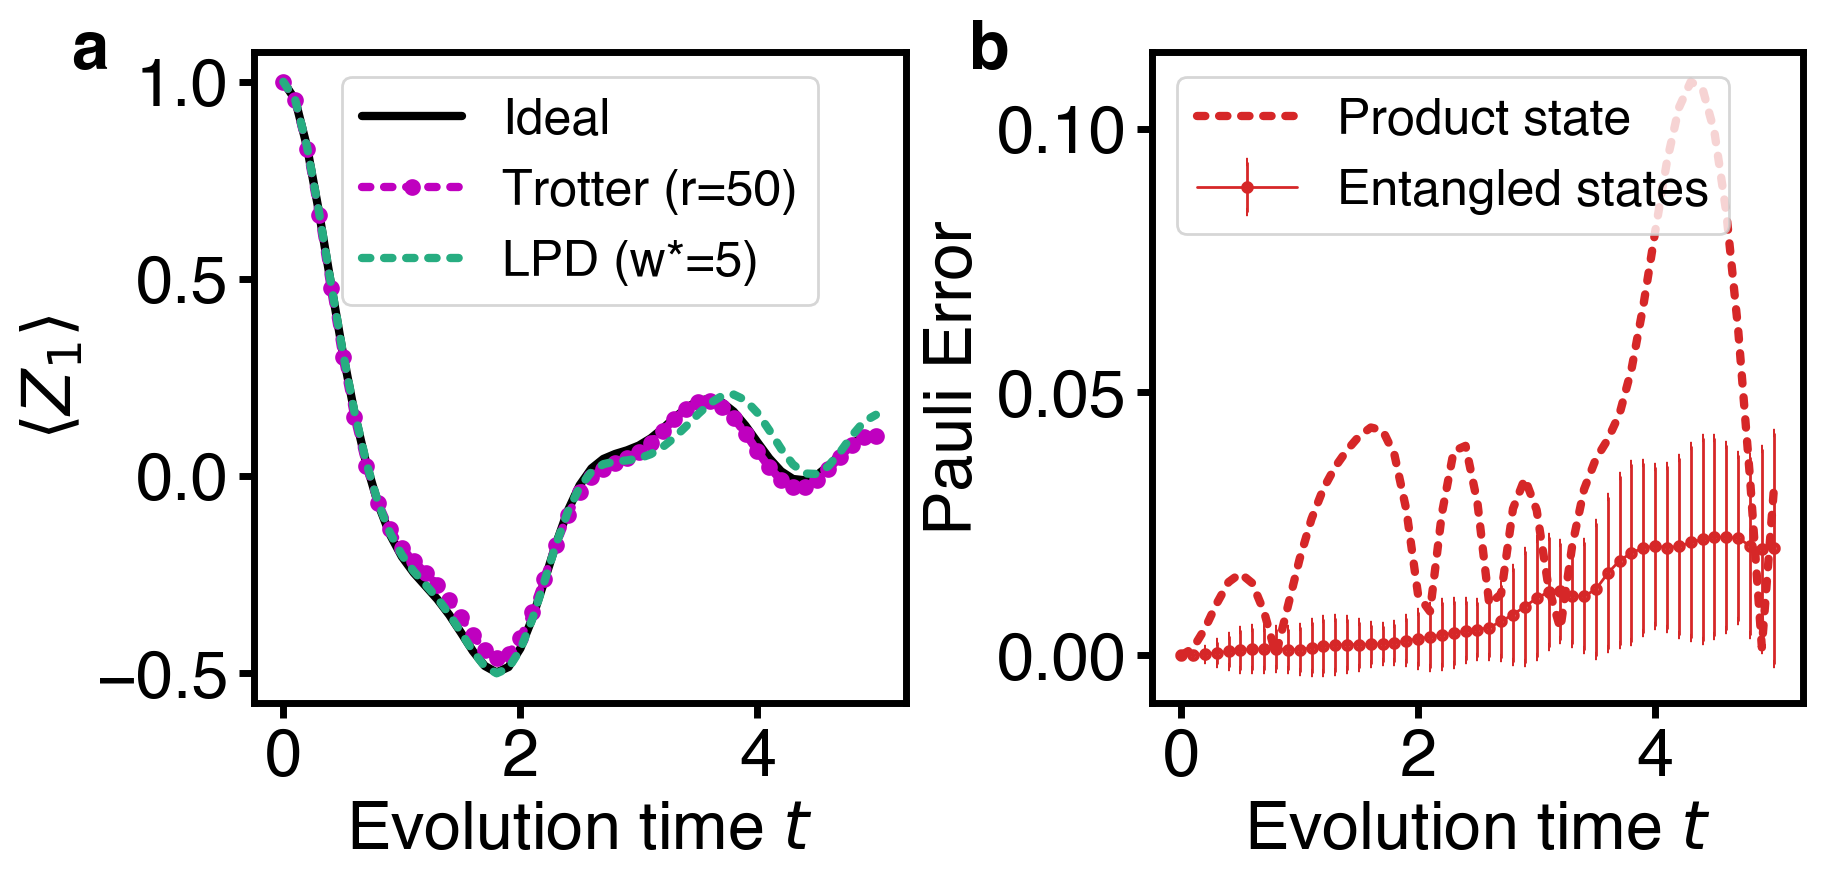

In [30]:
cc = default_color_cycle

t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num_dense
t_list = np.array(range(len(trott_expvals))) * dt
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))
# colors = plt.cm.plasma(np.linspace(0.3, 0.9, n))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.3), layout='constrained') 
axes[0].plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='k')
axes[0].plot(t_list, trott_expvals, ':.', label=f'Trotter (r={r})', c="m", ms=6)
# axes[0].plot(t_list, res.real, '--', label=f'LPD (w*={w_thres})', c=colors[w_thres-1])
axes[0].plot(t_list, res1.real, ':', label=f'LPD (w*={w_thres+1})', c=colors[w_thres])
axes[0].set_xlabel(rf'Evolution time $t$'); 
axes[0].set_ylabel(rf'$\langle Z_1 \rangle$')
axes[0].legend(loc='upper center', fontsize=18, ncol=1)
# axes[0,0].set_title(rf'{H_model}, n={n}, t={t}, r={r}, init={init_state_str[:2]}')
# plt.rcParams["text.usetex"] = False

# axes[1].plot(t_list, pauli_diff_fnorm, '-', label=r'$||\tilde{O}^{(d)}-\tilde{O}^{(d)}_{\leq  w^*}||_{\bar{2}}$', c='tab:red')
# axes[1].plot(t_list, pauli_diff_fnorm, '-', label=r'Bound $||\tilde{O}^{(d)}-\tilde{O}^{(d)}_{\leq  w^*}||_{\bar{2}}$', c='tab:red')
# axes[1].errorbar(t_list, np.array(expvals_pauli_diff).mean(axis=1), yerr=np.array(expvals_pauli_diff).std(axis=1), fmt='.-', label=r'$\mathbb{\text{E}}_{\rho}|\text{Tr}((\tilde{O}^{(d)}-\tilde{O}^{(d)}_{\leq w^*})\rho)|$', c='tab:red', capsize=0.5, lw=1, ms=3)
axes[1].errorbar(t_list, np.array(expvals_pauli_diff).mean(axis=1), yerr=np.array(expvals_pauli_diff).std(axis=1), fmt='.-', label=r'Entangled states', c='tab:red', capsize=0.5, lw=1, ms=3)
axes[1].plot(t_list, abs(trott_expvals-res), ':', label=r'Product state', c='tab:red')
# axes[1].plot(t_list, abs(trott_expvals-res), ':', label=r'$|\langle\psi_0 |(\tilde{O}^{(d)}-\tilde{O}^{(d)}_{\leq w^*})|\psi_0\rangle|$', c='tab:red')
# axes[1].plot(t_list, abs(trott_expvals-res), ':', label=r'$|01\cdots 01\rangle $', c='tab:red')
axes[1].set_ylabel(rf'Pauli Error'); axes[1].legend(loc='upper left', fontsize=18)
# axes[1].legend(loc='upper left', fontsize='small')
axes[1].set_xlabel(rf'Evolution time $t$'); 

for ax, label in zip(axes.flatten(), ['a', 'b']): 
    ax.text(-0.28, 1.05, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/LPD_{H_model}_n={n}_t={t}_r={r}_w={w_thres}_{init_state_str[:4]}_PF2_label.pdf', bbox_inches='tight')

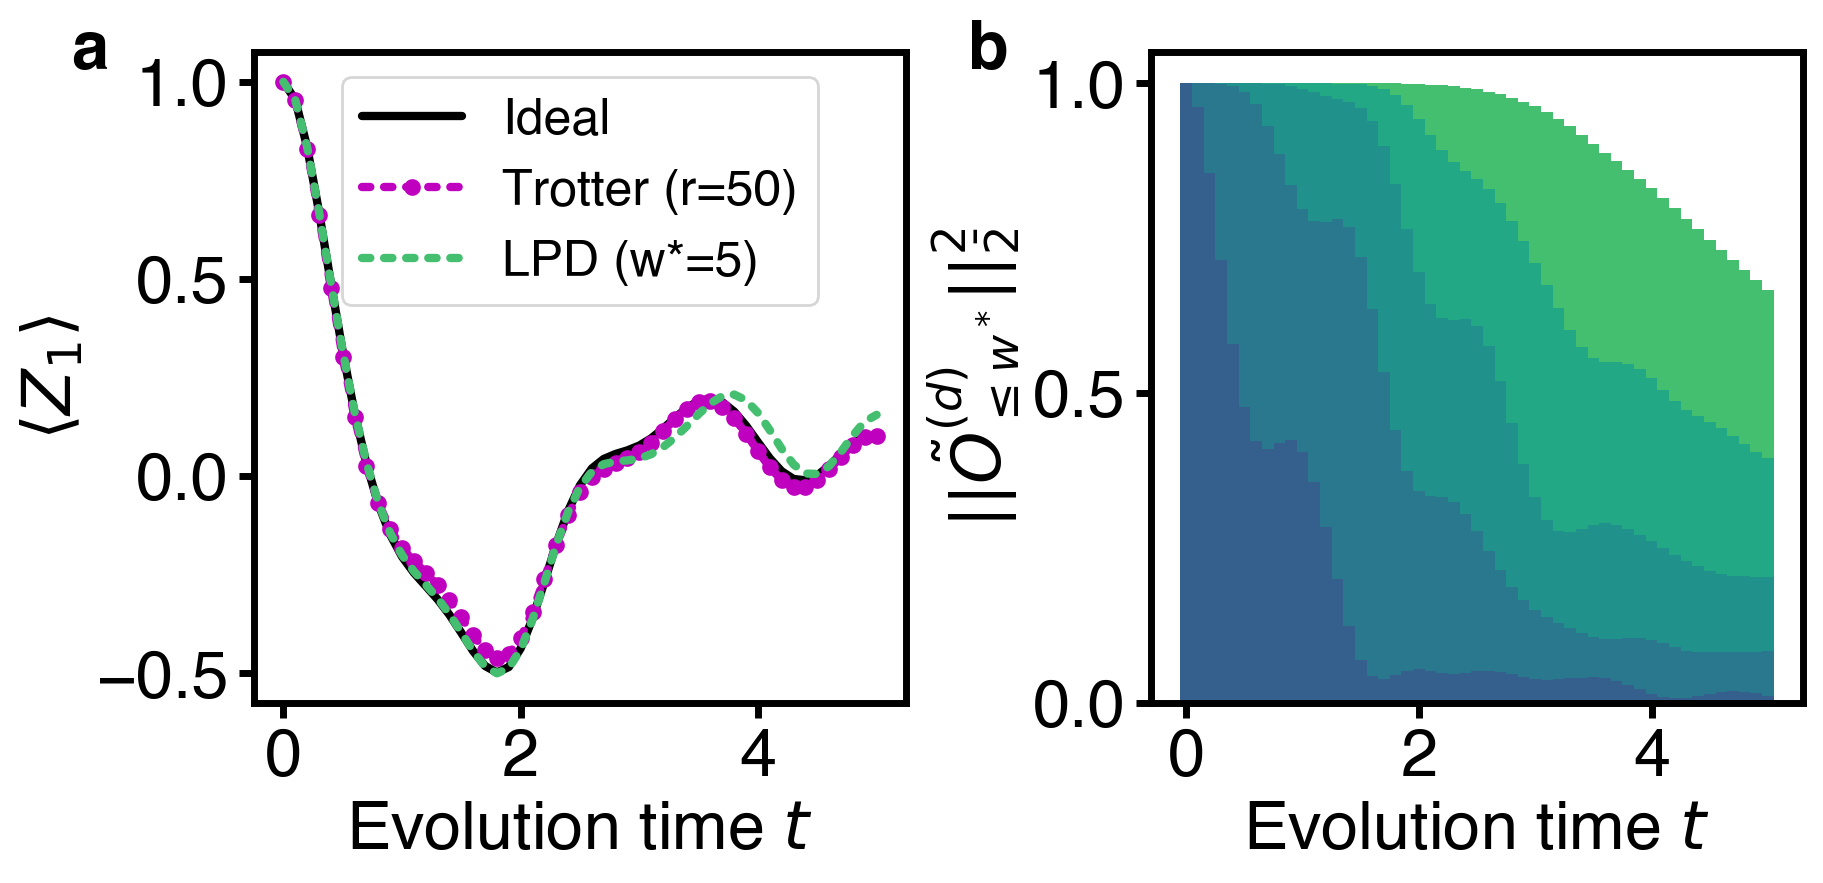

In [27]:
cc = default_color_cycle

t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num_dense
t_list = np.array(range(len(trott_expvals))) * dt
colors = plt.cm.viridis(np.linspace(0.3, 1.2, n))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.3), layout='constrained') 
axes[0].plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='k')
axes[0].plot(t_list, trott_expvals, ':.', label=f'Trotter (r={r})', c="m", ms=6)
axes[0].plot(t_list, res1.real, ':', label=f'LPD (w*={w_thres+1})', c=colors[w_thres])
axes[0].set_xlabel(rf'Evolution time $t$'); 
axes[0].set_ylabel(rf'$\langle Z_1 \rangle$')
axes[0].legend(loc='upper center', fontsize=18, ncol=1)

for w in range(n, 0, -1):
    norm2_distr = [sum(norm_weight_steps[i][:w]) for i in range(len(trott_expvals))]
    bars = axes[1].bar(t_list, norm2_distr, 0.1, color=colors[w-1], label=f'w<={w}')
axes[1].set_ylabel(r'$||\tilde{O}_{\leq w^*}^{(d)}||_{\bar{2}}^2$') 
axes[1].set_xlabel(rf'Evolution time $t$'); 

for ax, label in zip(axes.flatten(), ['a', 'b']): 
    ax.text(-0.28, 1.05, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/LPD_{H_model}_n={n}_t={t}_r={r}_w={w_thres}_{init_state_str[:4]}_PF2_cum_norm.pdf', bbox_inches='tight')

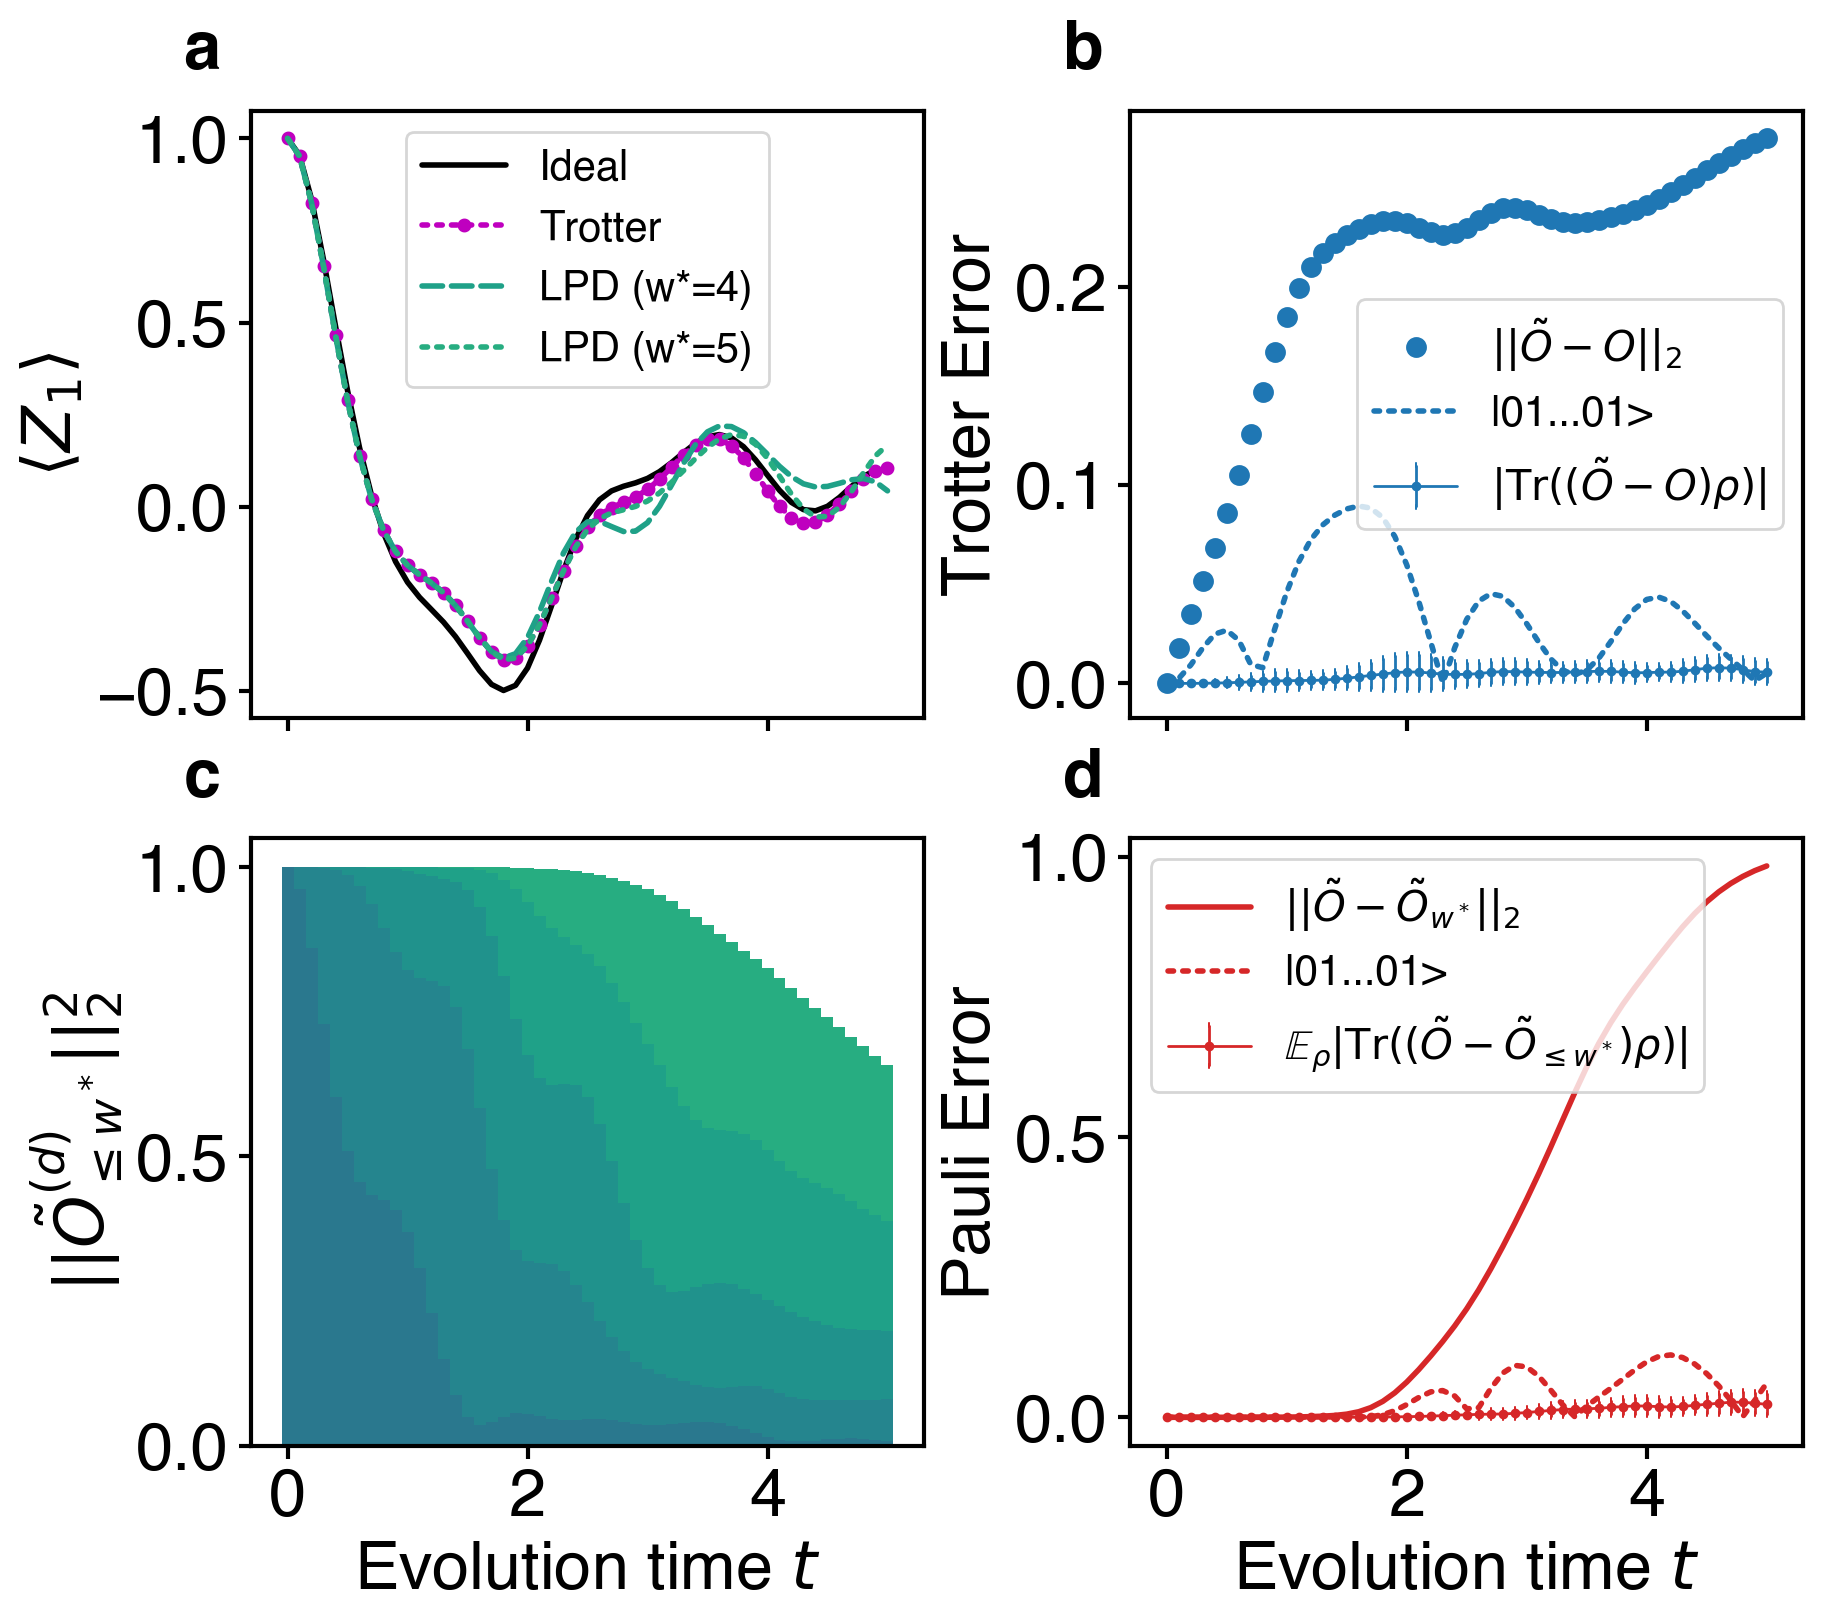

In [21]:
t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num_dense
t_list = np.array(range(len(trott_expvals))) * dt
colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))
# colors = plt.cm.plasma(np.linspace(0.3, 0.9, n))

fig, axes = plt.subplots(2, 2, sharex=True, figsize=(9, 8), layout='constrained') # , layout='constrained'
axes[0,0].plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='k')
axes[0,0].plot(t_list, trott_expvals, ':.', label='Trotter', c='m', ms=6)
axes[0,0].plot(t_list, res.real, '--', label=f'LPD (w*={w_thres})', c=colors[w_thres-1])
axes[0,0].plot(t_list, res1.real, ':', label=f'LPD (w*={w_thres+1})', c=colors[w_thres])
axes[1,0].set_xlabel(rf'Evolution time $t$'); 
axes[0,0].set_ylabel(rf'$\langle Z_1 \rangle$')
axes[0,0].legend(loc='upper center', fontsize='small', ncol=1)
# axes[0,0].set_title(rf'{H_model}, n={n}, t={t}, r={r}, init={init_state_str[:2]}')

axes[1,1].plot(t_list, pauli_diff_fnorm, '-', label=r'$||\tilde{O}-\tilde{O}_{ w^*}||_2$', c='tab:red')
axes[1,1].errorbar(t_list, np.array(expvals_pauli_diff).mean(axis=1), yerr=np.array(expvals_pauli_diff).std(axis=1), fmt='.-', label=r'$\mathbb{E}_{\rho}|\text{Tr}((\tilde{O}-\tilde{O}_{\leq w^*})\rho)|$', c='tab:red', capsize=0.5, lw=1, ms=3)
axes[1,1].plot(t_list, abs(trott_expvals-res), ':', label=f'|01...01>', c='tab:red')
axes[1,1].set_ylabel(rf'Pauli Error'); axes[1,1].legend(loc='upper left', fontsize='small')
axes[1,1].set_xlabel(rf'Evolution time $t$'); 
axes[0,1].plot(t_list, trott_diff_fnorm, '.', label=r'$||\tilde{O}-O||_2$', c='tab:blue')
axes[0,1].errorbar(t_list, np.array(expvals_trott_diff).mean(axis=1), yerr=np.array(expvals_trott_diff).std(axis=1), fmt='.-', label=r'$|\text{Tr}((\tilde{O}-O)\rho)|$', c='tab:blue', capsize=0.5, lw=1, ms=3)
axes[0,1].plot(t_list, abs(np.array(trott_expvals)-np.array(ideal_expvals)), ':', label=f'|01...01>', c='tab:blue')
axes[0,1].set_ylabel(rf'Trotter Error'); axes[0,1].legend(loc='center right', fontsize='small')

for w in range(n, 0, -1):
    norm2_distr = [sum(norm_weight_steps[i][:w]) for i in range(len(trott_expvals))]
    # if w<=7: print(f'w>={w+1},', 1-norm2_distr[-1])
    bars = axes[1,0].bar(t_list, norm2_distr, 0.1, color=colors[w-1], label=f'w<={w}')
axes[1,0].set_ylabel(r'$||\tilde{O}_{\leq w^*}^{(d)}||_2^2$') # axes[1,0].legend(loc='upper right')

for ax, label in zip(axes.flatten(), ['a', 'b', 'c', 'd']): 
    ax.text(-0.10, 1.15, label, transform=ax.transAxes, fontsize=24, va='top', weight='bold')

fig.savefig(f'{fig_dir}/LPD_{H_model}_n={n}_t={t}_r={r}_w={w_thres}_{init_state_str[:4]}_2design.pdf', bbox_inches='tight')

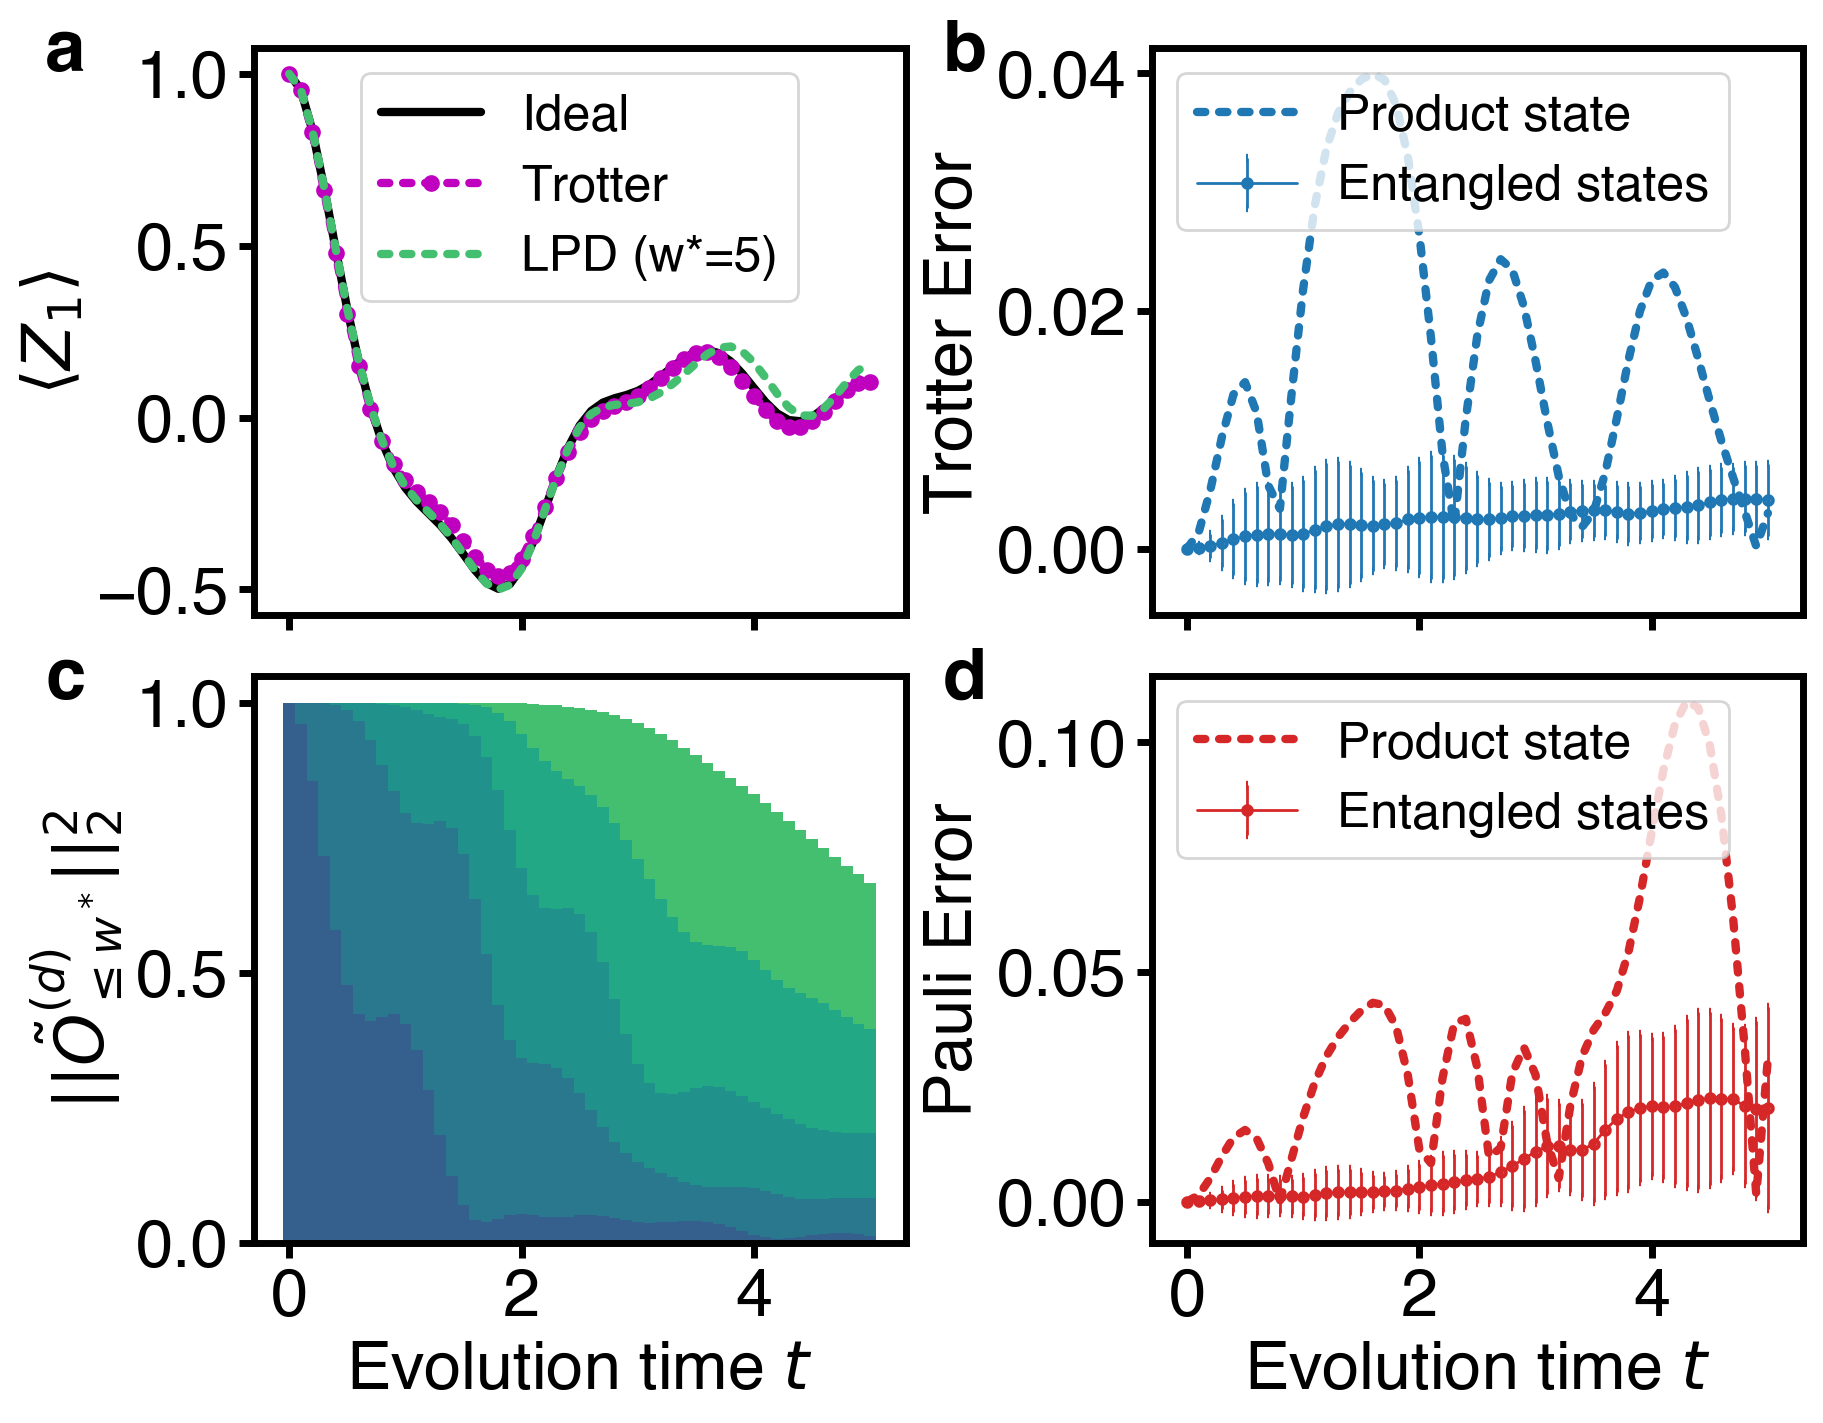

In [57]:
t_dense_list = np.array(range(len(ideal_expvals))) * t/t_num_dense
t_list = np.array(range(len(trott_expvals))) * dt
# colors = plt.cm.viridis(np.linspace(0.4, 0.9, n))
colors = plt.cm.viridis(np.linspace(0.3, 1.2, n))
# colors = plt.cm.plasma(np.linspace(0.3, 0.9, n))

fig, axes = plt.subplots(2, 2, sharex=True, figsize=(9, 7), layout='constrained') # , layout='constrained'
axes[0,0].plot(t_dense_list, ideal_expvals, '-', label='Ideal', c='k')
axes[0,0].plot(t_list, trott_expvals, ':.', label='Trotter', c='m', ms=6)
# axes[0,0].plot(t_list, res.real, '--', label=f'LPD (w*={w_thres})', c=colors[w_thres-1])
axes[0,0].plot(t_list, res1.real, ':', label=f'LPD (w*={w_thres+1})', c=colors[w_thres])
axes[1,0].set_xlabel(rf'Evolution time $t$'); 
axes[0,0].set_ylabel(rf'$\langle Z_1 \rangle$')
axes[0,0].legend(loc='upper center', fontsize=18, ncol=1)
# axes[0,0].set_title(rf'{H_model}, n={n}, t={t}, r={r}, init={init_state_str[:2]}')

# axes[1,1].plot(t_list, pauli_diff_fnorm, '-', label=r'$||\tilde{O}-\tilde{O}_{ w^*}||_2$', c='tab:red')
axes[1,1].errorbar(t_list, np.array(expvals_pauli_diff).mean(axis=1), yerr=np.array(expvals_pauli_diff).std(axis=1), fmt='.-', label=r'Entangled states', c='tab:red', capsize=0.5, lw=1, ms=3)
axes[1,1].plot(t_list, abs(trott_expvals-res), ':', label=f'Product state', c='tab:red')
axes[1,1].set_ylabel(rf'Pauli Error'); axes[1,1].legend(loc='upper left', fontsize=18)
axes[1,1].set_xlabel(rf'Evolution time $t$'); 
# axes[0,1].plot(t_list, trott_diff_fnorm, '.', label=r'$||\tilde{O}-O||_2$', c='tab:blue')
axes[0,1].errorbar(t_list, np.array(expvals_trott_diff).mean(axis=1), yerr=np.array(expvals_trott_diff).std(axis=1), fmt='.-', label=r'Entangled states', c='tab:blue', capsize=0.5, lw=1, ms=3)
axes[0,1].plot(t_list, abs(np.array(trott_expvals)-np.array(ideal_expvals)), ':', label=f'Product state', c='tab:blue')
axes[0,1].set_ylabel(rf'Trotter Error'); axes[0,1].legend(loc='upper left', fontsize=18)

for w in range(n, 0, -1):
    norm2_distr = [sum(norm_weight_steps[i][:w]) for i in range(len(trott_expvals))]
    # if w<=7: print(f'w>={w+1},', 1-norm2_distr[-1])
    bars = axes[1,0].bar(t_list, norm2_distr, 0.1, color=colors[w-1], label=f'w<={w}')
axes[1,0].set_ylabel(r'$||\tilde{O}_{\leq w^*}^{(d)}||_2^2$') # axes[1,0].legend(loc='upper right')

for ax, label in zip(axes.flatten(), ['a', 'b', 'c', 'd']): 
    ax.text(-0.32, 1.05, label, transform=ax.transAxes, fontsize=26, va='top', weight='bold')

fig.savefig(f'{fig_dir}/LPD_{H_model}_n={n}_t={t}_r={r}_w={w_thres}_{init_state_str[:4]}_PF2_four.pdf', bbox_inches='tight')